Ce TP est une étude approfondie des techniques d'amélioration et de segmentation d'images. Il combine l'analyse statistique des intensités, le filtrage dans le domaine fréquentiel (Fourier) et les opérations géométriques (morphologie).

**Contenu du Notebook :**
* **Analyse de l'Histogramme :** Visualisation de la distribution des intensités, calcul de l'histogramme cumulé et manipulation de la dynamique (translation à gauche/droite) et égalisation.
* **Détection de Contours Spatiale :** Application des filtres de Sobel et calcul du module du gradient pour extraire les contours.
* **Domaine Fréquentiel (FFT) :** Application de filtres passe-bas et passe-haut sur la transformée de Fourier en faisant varier la fréquence de coupure.
* **Opérations Morphologiques :** Nettoyage et analyse de formes via l'érosion, la dilatation et le calcul du contour morphologique.

In [ ]:
pip install opencv-python

# Lecture de l'image:

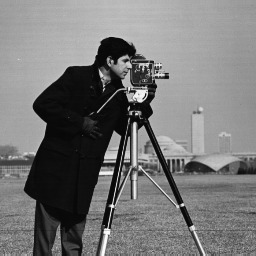

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Lecture de l'image

image = cv2.imread("/content/cameraman.jpg")
cv2_imshow(image)


# Son histogramme:

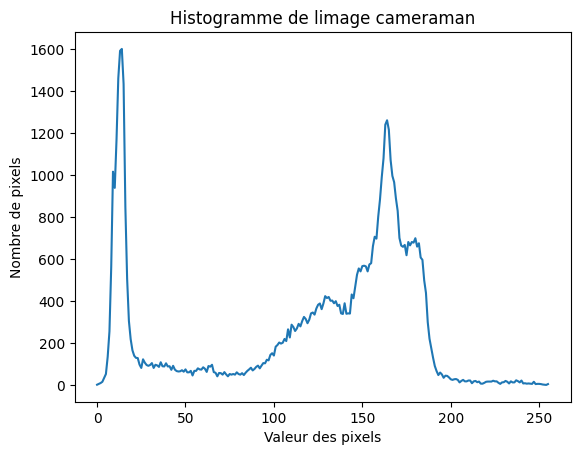

In [ ]:
# Calculer l'histogramme
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

# Tracer l'histogramme
plt.plot(hist)
plt.title('Histogramme de l''image cameraman')
plt.xlabel('Valeur des pixels')
plt.ylabel('Nombre de pixels')
plt.show()

L'histogramme permet d'avoir un overview sur la distribution des valeurs des pixels de l'image.

# Translation de l'histogramme

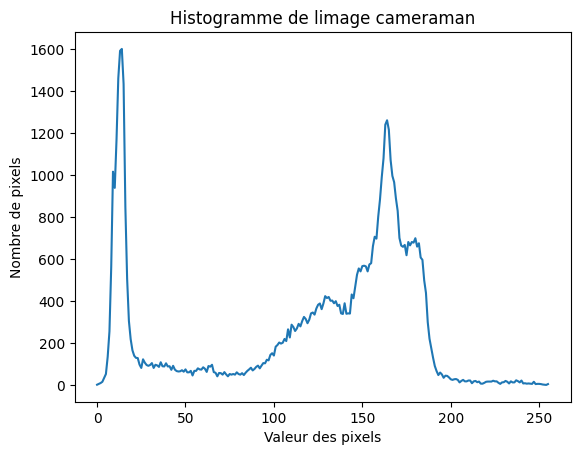

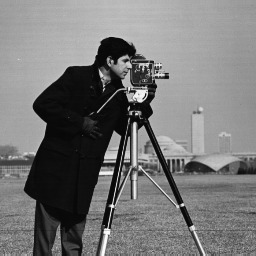

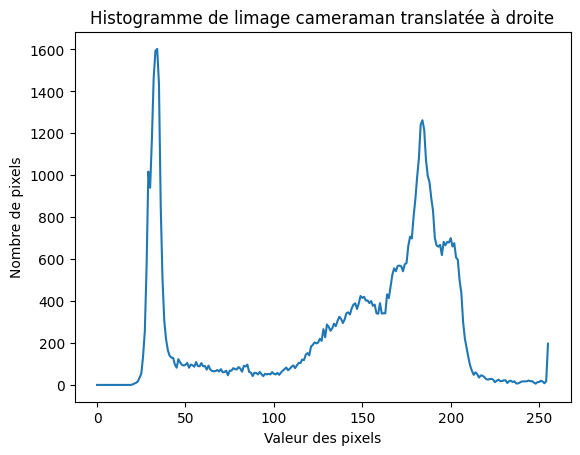

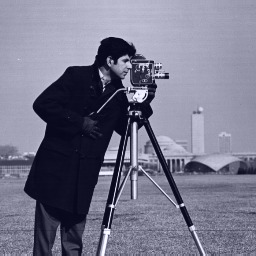

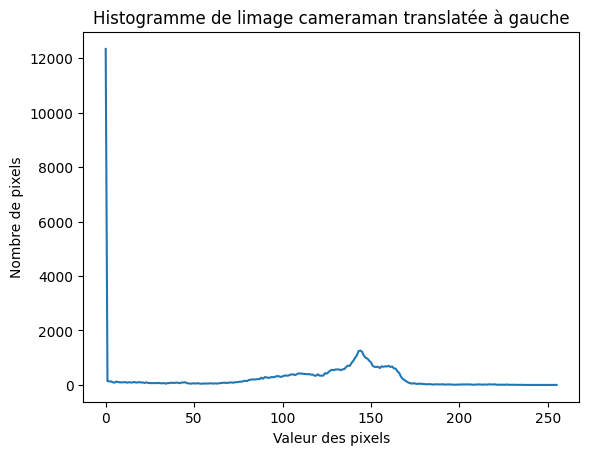

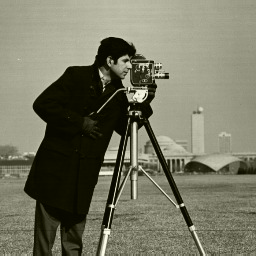

In [ ]:
# Lire l'image en niveaux de gris

# Définir les valeurs de translation
valeur_droite = 20
valeur_gauche = -20

# Translater l'histogramme vers la droite
img_droite = cv2.add(image, valeur_droite, dtype=cv2.CV_8U)

# Translater l'histogramme vers la gauche
img_gauche = cv2.add(image, valeur_gauche, dtype=cv2.CV_8U)

# Afficher les images et leurs histogrammes
hist = cv2.calcHist([image], [0], None, [256], [0, 256])
hist_droite = cv2.calcHist([img_droite], [0], None, [256], [0, 256])
hist_gauche = cv2.calcHist([img_gauche], [0], None, [256], [0, 256])
# Tracer l'histogramme
plt.plot(hist)
plt.title('Histogramme de l''image cameraman')
plt.xlabel('Valeur des pixels')
plt.ylabel('Nombre de pixels')
plt.show()
cv2_imshow(image)

plt.plot(hist_droite)
plt.title('Histogramme de l''image cameraman translatée à droite')
plt.xlabel('Valeur des pixels')
plt.ylabel('Nombre de pixels')
plt.show()
cv2_imshow(img_droite)

plt.plot(hist_gauche)
plt.title('Histogramme de l''image cameraman translatée à gauche')
plt.xlabel('Valeur des pixels')
plt.ylabel('Nombre de pixels')
plt.show()
cv2_imshow(img_gauche)

# L'histogramme cumulé:

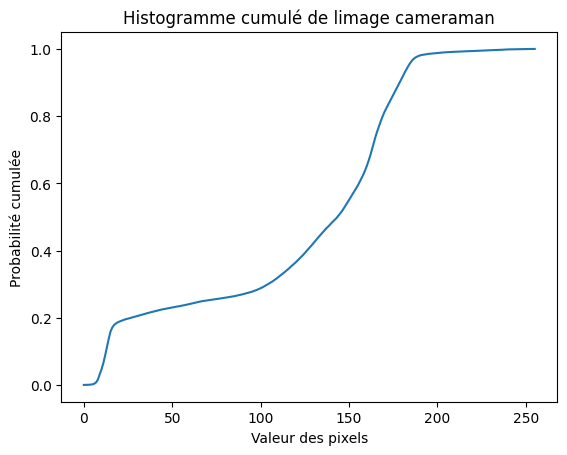

In [ ]:
# Calculer l'histogramme standard
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

# Calculer l'histogramme cumulé
hist_cum = np.cumsum(hist)

# Normaliser l'histogramme cumulé
hist_cum_norm = hist_cum / hist_cum[-1]

# Afficher l'histogramme cumulé
plt.plot(hist_cum_norm)
plt.title('Histogramme cumulé de l''image cameraman')
plt.xlabel('Valeur des pixels')
plt.ylabel('Probabilité cumulée')
plt.show()



# L’égalisation de l’histogramme sur l'image thumb_pout

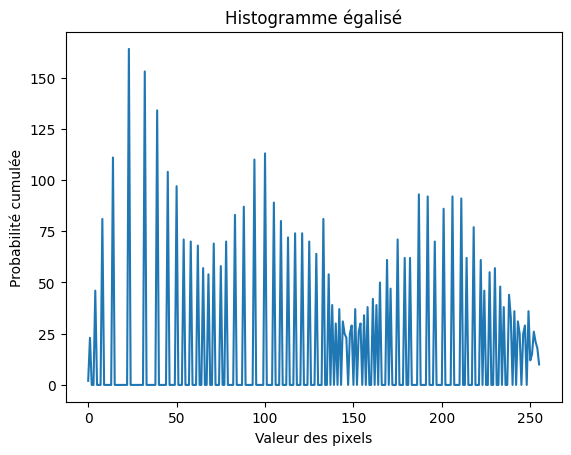

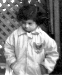

In [ ]:
import numpy as np

# Lire l'image en RVB
img = cv2.imread('/content/thumb_pout.png', cv2.IMREAD_COLOR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
newImg = cv2.equalizeHist(img)
newImg = cv2.equalizeHist(img)

hist = cv2.calcHist([newImg], [0], None, [256], [0, 256])
plt.plot(hist)
plt.title('Histogramme égalisé')
plt.xlabel('Valeur des pixels')
plt.ylabel('Probabilité cumulée')
plt.show()
cv2_imshow(newImg)

# Masque de Sobel Wx et Wy

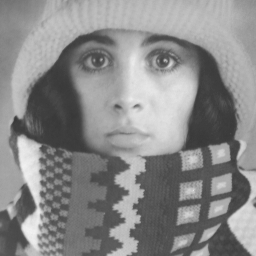

In [ ]:

image_trui = cv2.imread("/content/trui.png")
image_trui = cv2.cvtColor(image_trui, cv2.COLOR_BGR2GRAY)
cv2_imshow(image_trui)

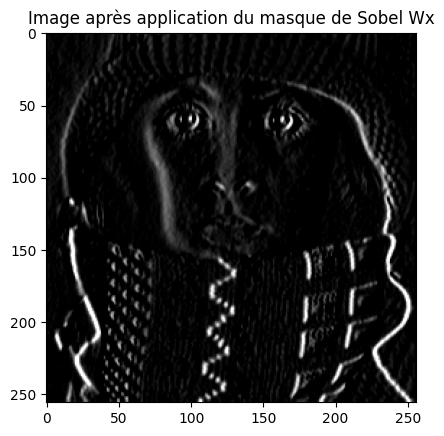

In [ ]:
sobel_wx = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]])
img_sobel_wx = cv2.filter2D(image_trui, ddepth=-1, kernel=sobel_wx)
plt.imshow(img_sobel_wx, cmap='gray')
plt.title('Image après application du masque de Sobel Wx')
plt.show()

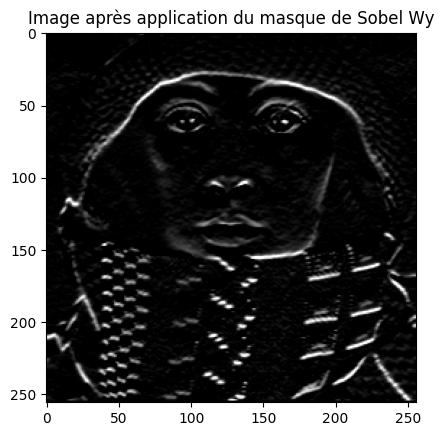

In [ ]:
sobel_wy = np.array([[1, 2, 1],
                     [0, 0, 0],
                     [-1, -2, -1]])
img_sobel_wy = cv2.filter2D(image_trui, ddepth=-1, kernel=sobel_wy)
plt.imshow(img_sobel_wy, cmap='gray')
plt.title('Image après application du masque de Sobel Wy')
plt.show()

On remarque que le filtre de Sobel Wx permet d'extraire les contours dans le sens vertical et de les accentuer, par contre le filtre Wy permet d'accentuer les contours dans le sens horizontal.


# L'image qui donne le module du gradient

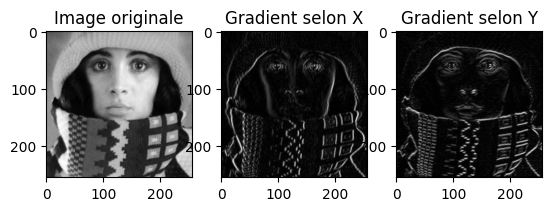

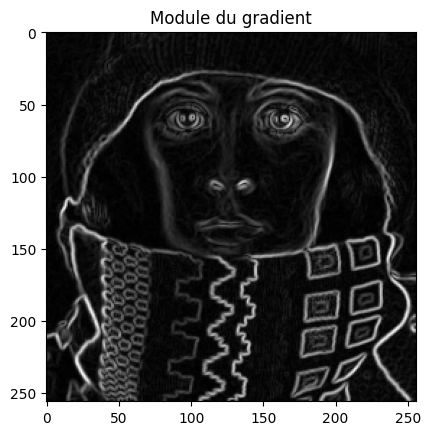

In [ ]:
# Charger l'image trui.png
trui_image = cv2.imread('/content/trui.png', cv2.IMREAD_GRAYSCALE)

# Appliquer les masques de Sobel (Wx et Wy)
sobel_x = cv2.Sobel(trui_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(trui_image, cv2.CV_64F, 0, 1, ksize=3)

# Calculer le module du gradient
gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Afficher le résultat
plt.subplot(131), plt.imshow(trui_image, cmap='gray'), plt.title('Image originale')
plt.subplot(132), plt.imshow(np.abs(sobel_x), cmap='gray'), plt.title('Gradient selon X')
plt.subplot(133), plt.imshow(np.abs(sobel_y), cmap='gray'), plt.title('Gradient selon Y')
plt.show()

# Afficher l'image qui donne le module du gradient
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Module du gradient')
plt.show()


Le module du gradient permet d'accentuer les contours de l'image et les rend plus visibles.

# Comparaison avec les resultats de matlab
Les résultats obtenus avec Python et Matlab sont pratiquement identiques, avec des structures, des contours et des intensités très similaires. La différence principale réside dans une légère variation du niveau de bruit et de la finesse des images.

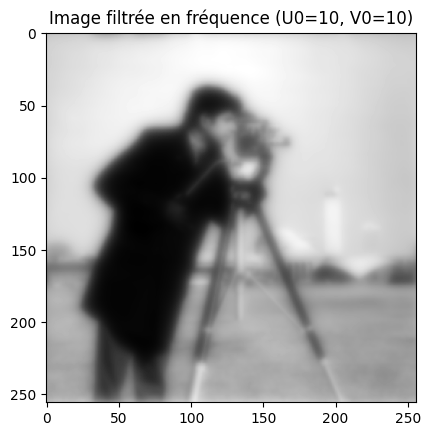

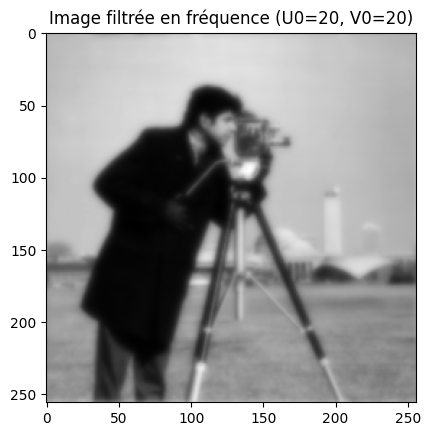

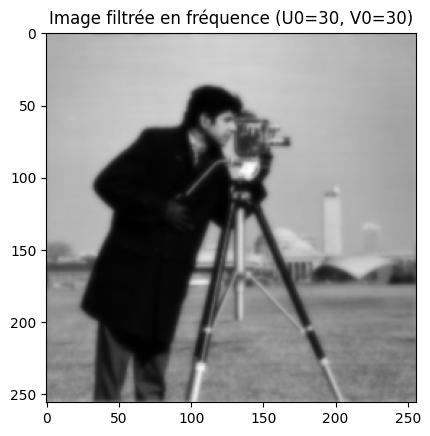

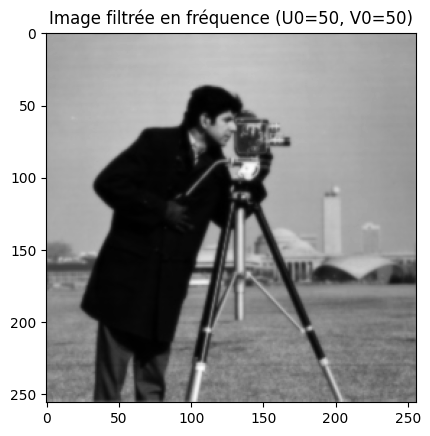

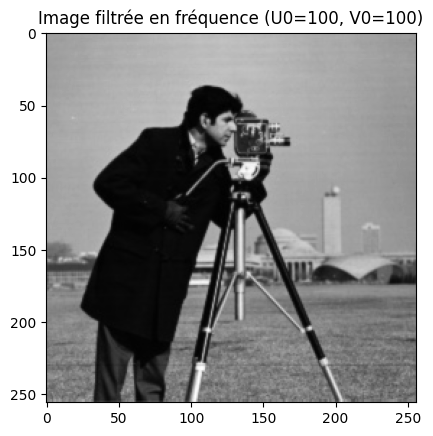

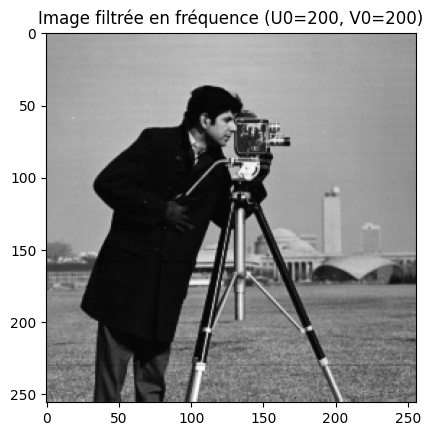

In [ ]:

# Charger l'image cameraman
cameraman_image = cv2.imread('cameraman.jpg', cv2.IMREAD_GRAYSCALE)

# Générer la transformée de Fourier de l'image cameraman
cameraman_fft = np.fft.fft2(cameraman_image)
cameraman_fft_shifted = np.fft.fftshift(cameraman_fft)

# Initialiser les fréquences de coupure (U0, V0)
cutoff_frequencies = [(10, 10), (20, 20), (30, 30),(50,50),(100,100), (200,200)]

# Appliquer le filtre passe-bas avec différentes fréquences de coupure
for u0, v0 in cutoff_frequencies:
    rows, cols = cameraman_image.shape
    lpf = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            lpf[i, j] = 1 / (1 + ((i - rows/2)/u0)**2 + ((j - cols/2)/v0)**2)

    # Appliquer le filtre dans le domaine fréquentiel
    filtered_image_fft = cameraman_fft_shifted * lpf

    # Transformation inverse de Fourier
    filtered_image = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered_image_fft)))

    # Afficher le résultat
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f'Image filtrée en fréquence (U0={u0}, V0={v0})')
    plt.show()



Conclusion : on remarque que plus la fréquence augmente plus l'image resultante est moins floutée et est plus claire et visible donc le filtre ne fait plus grand chose et ceci est du au fait que l'effet du filtre est de réduire les hautes fréquences dans l'image, ce qui a pour effet de lisser l'image et de réduire les détails fins (comme le bruit ou les contours fins). Lorsque la fréquence de coupure du filtre passe-bas augmente, le filtre laisse passer un plus grand nombre de hautes fréquences, entraînant une image résultante moins floutée, plus claire et avec plus de détails.





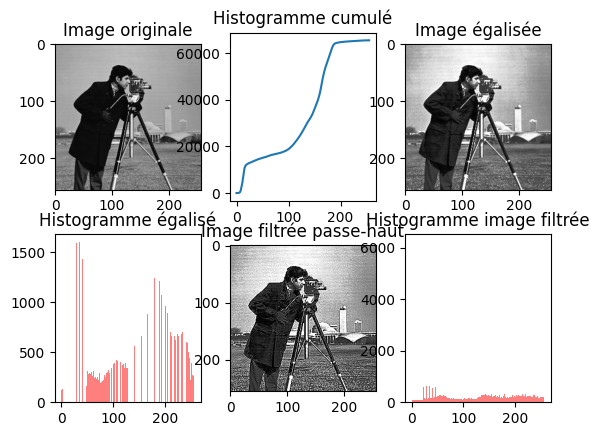

In [ ]:

from matplotlib import pyplot as plt

# Charger l'image cameraman.jpeg
cameraman_image = cv2.imread('/content/cameraman.jpg', cv2.IMREAD_GRAYSCALE)

# Calculer l'histogramme cumulé de l'image initiale
cumulative_hist = np.cumsum(cv2.calcHist([cameraman_image], [0], None, [256], [0, 256]))

# Faire l'égalisation de l'histogramme
equalized_image = cv2.equalizeHist(cameraman_image)

# Filtre passe-haut simple (kernel de convolution)
kernel_passe_haut = np.array([[0, -1, 0],
                              [-1, 5, -1],
                              [0, -1, 0]])

# Appliquer le filtre passe-haut à l'image égalisée
filtered_image = cv2.filter2D(equalized_image, -1, kernel_passe_haut)

# Afficher les résultats
plt.subplot(231), plt.imshow(cameraman_image, cmap='gray'), plt.title('Image originale')
plt.subplot(232), plt.plot(cumulative_hist), plt.title('Histogramme cumulé')
plt.subplot(233), plt.imshow(equalized_image, cmap='gray'), plt.title('Image égalisée')
plt.subplot(234), plt.hist(equalized_image.flatten(), bins=256, range=[0,256], color='r', alpha=0.5), plt.title('Histogramme égalisé')
plt.subplot(235), plt.imshow(filtered_image, cmap='gray'), plt.title('Image filtrée passe-haut')
plt.subplot(236), plt.hist(filtered_image.flatten(), bins=256, range=[0,256], color='r', alpha=0.5), plt.title('Histogramme image filtrée')
plt.show()


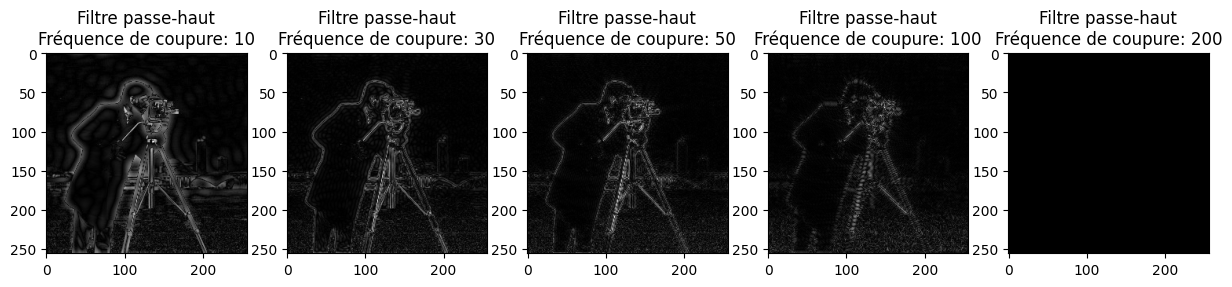

In [ ]:


# Charger l'image cameraman.jpeg
cameraman_image = cv2.imread('/content/cameraman.jpg', cv2.IMREAD_GRAYSCALE)

# Calculer la transformée de Fourier de l'image
cameraman_fft = np.fft.fft2(cameraman_image)
cameraman_fft_shifted = np.fft.fftshift(cameraman_fft)

# Dimensions de l'image
rows, cols = cameraman_image.shape

# Liste des fréquences de coupure
cutoff_frequencies = [10, 30,50, 100,200]

# Afficher les résultats pour chaque fréquence de coupure
plt.figure(figsize=(15, 5))

for i, cutoff_frequency in enumerate(cutoff_frequencies, 1):
    # Filtre passe-haut simple (kernel)
    hp_filter = np.ones((rows, cols), np.uint8)
    center_row, center_col = rows // 2, cols // 2
    cv2.circle(hp_filter, (center_col, center_row), cutoff_frequency, 0, -1)

    # Appliquer le filtre passe-haut dans le domaine fréquentiel
    filtered_image_fft = cameraman_fft_shifted * hp_filter

    # Transformation inverse de Fourier
    filtered_image = np.abs(np.fft.ifft2(np.fft.ifftshift(filtered_image_fft)))

    # Afficher les résultats pour chaque fréquence de coupure
    plt.subplot(1, len(cutoff_frequencies), i)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f'Filtre passe-haut\nFréquence de coupure: {cutoff_frequency}')

plt.show()


on remarque que plus on augmente la fréquence de coupure du filtre plus les hautes fréquences dominent et l'image ne cesse de noircir et pour une certaine fréquence elle devient complétement noire. Donc lorsque la fréquence de coupure d'un filtre passe-haut devient très élevée, le filtre accentue de plus en plus les hautes fréquences, ce qui peut conduire à une perte d'informations importantes dans l'image. Lorsque la fréquence atteint un point où la plupart des hautes fréquences sont supprimées, l'image filtrée peut apparaître comme totalement noire.

# L'erosion :

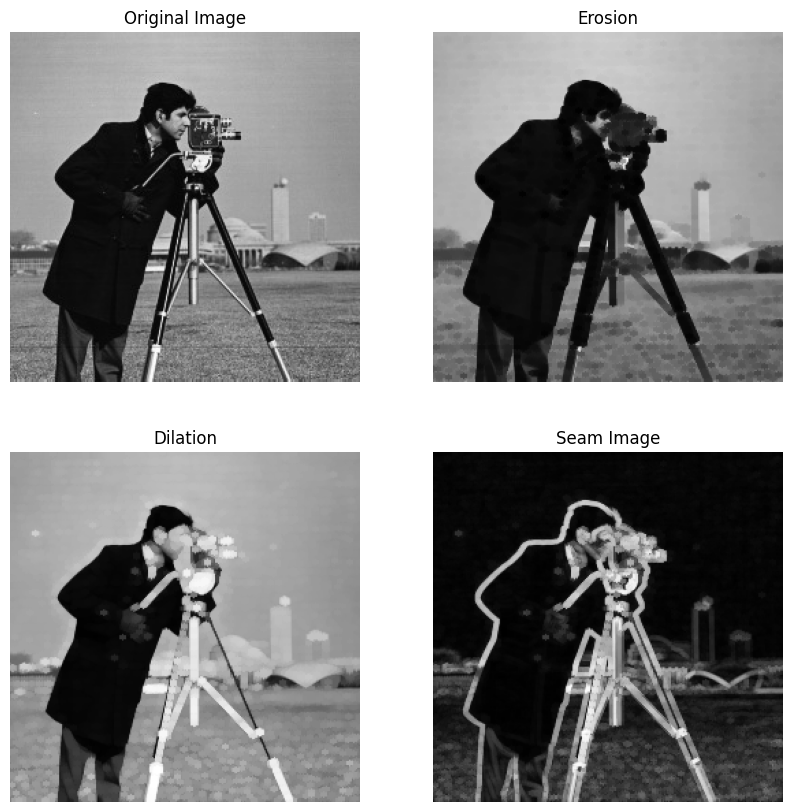

In [ ]:


# Charger l'image cameraman
image = cv2.imread('/content/cameraman.jpg', cv2.IMREAD_GRAYSCALE)

# Définir l'élément structurant (disque)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)) # Changer la taille selon les besoins

# Appliquer l'érosion
erosion = cv2.erode(image, kernel, iterations=1)

# Appliquer la dilatation
dilation = cv2.dilate(image, kernel, iterations=1)

# Appliquer une opération de fermeture (dilatation suivie d'une érosion)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)

# Trouver l'image de la couture (différence entre l'image originale et l'image fermée)
seam_image = cv2.absdiff(dilation, erosion)

# Enregistrer les images sur le disque
cv2.imwrite('original_image.jpg', image)
cv2.imwrite('erosion.jpg', erosion)
cv2.imwrite('dilation.jpg', dilation)
cv2.imwrite('seam_image.jpg', seam_image)

# Afficher les résultats à l'aide de matplotlib
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(erosion, cmap='gray')
plt.title('Erosion')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(dilation, cmap='gray')
plt.title('Dilation')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(seam_image, cmap='gray')
plt.title('contour morphologique')
plt.axis('off')

plt.show()

- On observe que l'érosion élimine les petits points clairs et les détails fins. Les zones sombres s'étendent, ce qui a pour effet de "nettoyer" les bruits isolés.
À l'inverse, la dilatation intensifie les zones claires. Les objets blancs s'élargissent, ce qui permet de combler les petites lacunes à l'intérieur des formes.

- Contour Morphologique : Cette opération (différence entre dilatation et érosion) permet d'extraire efficacement les contours des objets.
ur l'image résultante, on voit clairement que les silhouettes du cameraman, de sa caméra, ainsi que les lignes du bâtiment en arrière-plan sont bien détourées. Cela donne un tracé précis des frontières de chaque élément de la scène.